# Alias Coverage

Measure how well each alias config resolves raw GenBank qualifier values. Generated tables and figures are written to `outputs/`.

## What This Checks

This notebook validates the naming layer only. It scans raw qualifiers from annotated GenBank records, applies the same alias lookup used by ViraLift, and separates outcomes into:

- `canonical`: resolved to a usable target name
- `ambiguous`: known shared/generic name, intentionally not mapped
- `ignored`: known non-target/generic annotation text
- `unresolved`: not covered by the alias map yet

Coverage percent counts only `canonical` as covered. `ignored` still lowers coverage so we can see noisy annotation fields instead of hiding them.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

STATUS_ORDER = ['canonical', 'ambiguous', 'ignored', 'unresolved']
STATUS_COLORS = {
    'canonical': '#2f7d4f',
    'ambiguous': '#d6a13d',
    'ignored': '#7b8794',
    'unresolved': '#c44e52',
}


## Load Raw Qualifier Values

Each row below is one qualifier occurrence from `CDS` or `mat_peptide`, before alias resolution.

In [2]:
DATASETS = [
    ('PRRS', CROSS_CHECK / 'PRRS_100seq_anno.gb', CONFIG / 'prrsv_alias.json'),
    ('FMD', CROSS_CHECK / 'FMD_100seq_anno.gb', CONFIG / 'fmdv_alias.json'),
]

rows = []
for virus, query_path, alias_path in DATASETS:
    records = load_genbank_records(query_path)
    alias_lookup = load_alias_lookup(alias_path)
    raw_rows = collect_alias_rows(records)
    rows.append(evaluate_alias_rows(raw_rows, alias_lookup, virus))

alias_df = pd.concat(rows, ignore_index=True)
alias_df['status'] = alias_df['resolved_to'].where(alias_df['is_canonical'], alias_df['resolved_to'])
alias_df.loc[alias_df['is_canonical'], 'status'] = 'canonical'
alias_df.to_csv(OUTPUT_DIR / 'alias_per_occurrence.tsv', sep='	', index=False)

alias_df.head()

,virus,record_id,feature_type,field,raw_value,resolved_to,is_canonical,status
0,PRRS,AF184212.1,CDS,product,ORF1a,ORF1a,True,canonical
1,PRRS,AF184212.1,CDS,note,cysteine/serine protease,ignored,False,ignored
2,PRRS,AF184212.1,CDS,product,ORF1b,ORF1b,True,canonical
3,PRRS,AF184212.1,CDS,note,RNA dependent RNA polymerase/helicase,ORF1b,True,canonical
4,PRRS,AF184212.1,CDS,product,ORF2,ORF2a,True,canonical


## Overall Coverage

`coverage_pct` counts every raw qualifier occurrence. `actionable_coverage_pct` excludes `ignored` names, so it better answers: among names worth mapping, how many did the alias config resolve?

In [3]:
overall_summary = (
    alias_df.groupby('virus')
    .agg(
        total=('raw_value', 'size'),
        canonical=('is_canonical', 'sum'),
        ambiguous=('status', lambda s: (s == 'ambiguous').sum()),
        ignored=('status', lambda s: (s == 'ignored').sum()),
        unresolved=('status', lambda s: (s == 'unresolved').sum()),
    )
    .reset_index()
)
overall_summary['coverage_pct'] = (overall_summary['canonical'] / overall_summary['total'] * 100).round(2)
overall_summary['actionable_total'] = overall_summary['total'] - overall_summary['ignored']
overall_summary['actionable_coverage_pct'] = (
    overall_summary['canonical'] / overall_summary['actionable_total'].where(overall_summary['actionable_total'] > 0) * 100
).round(2)
overall_summary.to_csv(OUTPUT_DIR / 'alias_summary_overall.tsv', sep='\t', index=False)
overall_summary

,virus,total,canonical,ambiguous,ignored,unresolved,coverage_pct,actionable_total,actionable_coverage_pct
0,FMD,1278,1178,0,100,0,92.18,1178,100.00
1,PRRS,1759,1609,79,68,3,91.47,1691,95.15


## Coverage By Feature Type And Field

Use this to tell whether weak coverage comes from a specific feature type (`CDS` vs `mat_peptide`) or from a noisy qualifier field (`product`, `note`, etc.).

In [4]:
def summarize_alias(group_cols):
    summary = (
        alias_df.groupby(group_cols, dropna=False)
        .agg(
            total=('raw_value', 'size'),
            canonical=('is_canonical', 'sum'),
            ambiguous=('status', lambda s: (s == 'ambiguous').sum()),
            ignored=('status', lambda s: (s == 'ignored').sum()),
            unresolved=('status', lambda s: (s == 'unresolved').sum()),
        )
        .reset_index()
    )
    summary['coverage_pct'] = (summary['canonical'] / summary['total'] * 100).round(2)
    summary['actionable_total'] = summary['total'] - summary['ignored']
    summary['actionable_coverage_pct'] = (
        summary['canonical'] / summary['actionable_total'].where(summary['actionable_total'] > 0) * 100
    ).round(2)
    return summary

summary_by_field = summarize_alias(['virus', 'feature_type', 'field'])
summary_by_feature_type = summarize_alias(['virus', 'feature_type'])
summary_by_virus_field = summarize_alias(['virus', 'field'])

summary_by_field.to_csv(OUTPUT_DIR / 'alias_summary_by_field.tsv', sep='	', index=False)
summary_by_feature_type.to_csv(OUTPUT_DIR / 'alias_summary_by_feature_type.tsv', sep='	', index=False)
summary_by_virus_field.to_csv(OUTPUT_DIR / 'alias_summary.tsv', sep='	', index=False)

summary_by_field.sort_values(['virus', 'feature_type', 'coverage_pct', 'field'])

,virus,feature_type,field,total,canonical,ambiguous,ignored,unresolved,coverage_pct,actionable_total,actionable_coverage_pct
0,FMD,CDS,product,100,0,0,100,0,0.00,0,NaN
1,FMD,mat_peptide,product,1178,1178,0,0,0,100.00,1178,100.00
3,PRRS,CDS,note,720,643,52,24,1,89.31,696,92.39
4,PRRS,CDS,product,836,768,27,40,1,91.87,796,96.48
2,PRRS,CDS,gene,183,183,0,0,0,100.00,183,100.00
5,PRRS,mat_peptide,note,8,5,0,2,1,62.50,6,83.33
6,PRRS,mat_peptide,product,12,10,0,2,0,83.33,10,100.00


## Non-Canonical Names To Review

This includes all names that did not become canonical: `ambiguous`, `ignored`, and `unresolved`. That is why FMD appears here even if its gaps are mostly intentionally ignored values such as `polyprotein`.

In [5]:
noncanonical = alias_df[~alias_df['is_canonical']].copy()
noncanonical_names = (
    noncanonical.groupby(['virus', 'feature_type', 'field', 'status', 'raw_value'])
    .size()
    .reset_index(name='count')
    .sort_values(['virus', 'status', 'count', 'raw_value'], ascending=[True, True, False, True])
)
virus_totals = alias_df.groupby('virus').size().rename('virus_total')
noncanonical_names = noncanonical_names.merge(virus_totals, on='virus')
noncanonical_names['occurrence_pct_of_virus'] = (noncanonical_names['count'] / noncanonical_names['virus_total'] * 100).round(2)
noncanonical_names = noncanonical_names.drop(columns='virus_total')
noncanonical_names.to_csv(OUTPUT_DIR / 'alias_noncanonical_names.tsv', sep='	', index=False)

# Backward-compatible filename for older notes/scripts, now with ignored included too.
noncanonical_names.to_csv(OUTPUT_DIR / 'alias_unmapped_names.tsv', sep='	', index=False)
noncanonical_names.head(50)

,virus,feature_type,field,status,raw_value,count,occurrence_pct_of_virus
0,FMD,CDS,product,ignored,polyprotein,100,7.82
1,PRRS,CDS,product,ambiguous,glycosylated membrane protein,18,1.02
2,PRRS,CDS,note,ambiguous,structural glycoprotein,18,1.02
3,PRRS,CDS,note,ambiguous,glycosylated membrane protein,13,0.74
4,PRRS,CDS,product,ambiguous,envelope protein,7,0.40
5,PRRS,CDS,note,ambiguous,glycosylated,6,0.34
6,PRRS,CDS,note,ambiguous,envelope protein,4,0.23
7,PRRS,CDS,note,ambiguous,glycoprotein,4,0.23
8,PRRS,CDS,note,ambiguous,envelope glycoprotein,3,0.17
9,PRRS,CDS,note,ambiguous,structural glycoprotein; viral attachment protein,3,0.17


## Top Raw Names

This view is useful when a single repeated raw value dominates coverage. `resolved_to` shows whether the alias map already handles it and where it lands.

In [6]:
top_raw_names = (
    alias_df.groupby(['virus', 'feature_type', 'field', 'status', 'resolved_to', 'raw_value'])
    .size()
    .reset_index(name='count')
    .sort_values(['virus', 'count', 'raw_value'], ascending=[True, False, True])
)
top_raw_names.to_csv(OUTPUT_DIR / 'alias_top_raw_names.tsv', sep='	', index=False)
top_raw_names.groupby('virus').head(20)

,virus,feature_type,field,status,resolved_to,raw_value,count
0,FMD,CDS,product,ignored,ignored,polyprotein,100
1,FMD,mat_peptide,product,canonical,2A,2A,50
3,FMD,mat_peptide,product,canonical,2B,2B,50
5,FMD,mat_peptide,product,canonical,2C,2C,50
7,FMD,mat_peptide,product,canonical,3A,3A,50
18,FMD,mat_peptide,product,canonical,3Cpro,3C,50
21,FMD,mat_peptide,product,canonical,3Dpol,3D,50
34,FMD,mat_peptide,product,canonical,VP2,VP2,50
38,FMD,mat_peptide,product,canonical,VP4,VP4,50
32,FMD,mat_peptide,product,canonical,VP1,VP1,49


## Chart: Outcome Mix

The stacked bars show whether low coverage is caused by names we deliberately ignored, names known to be ambiguous, or truly unresolved names.

status,virus,canonical,ambiguous,ignored,unresolved
0,FMD,1178,0,100,0
1,PRRS,1609,79,68,3


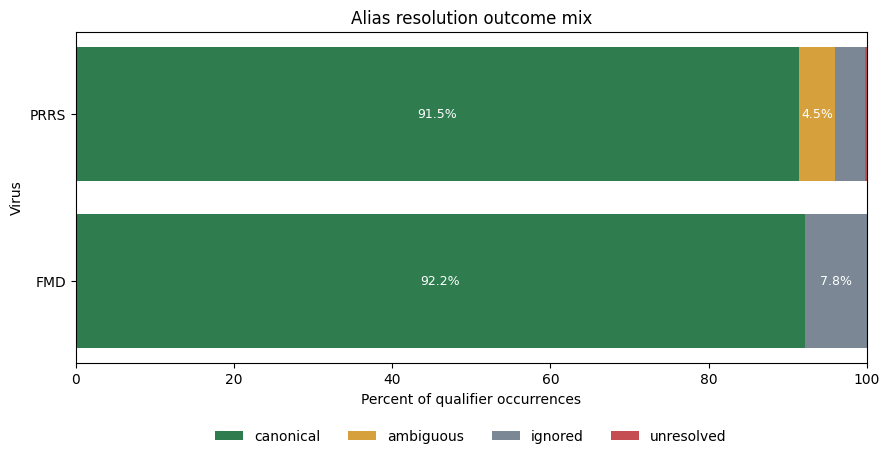

In [7]:
status_counts = (
    alias_df.groupby(['virus', 'status'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=STATUS_ORDER, fill_value=0)
)
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
left = pd.Series(0, index=status_pct.index, dtype=float)
for status in STATUS_ORDER:
    ax.barh(status_pct.index, status_pct[status], left=left, color=STATUS_COLORS[status], label=status)
    for virus in status_pct.index:
        value = status_pct.loc[virus, status]
        if value >= 4:
            ax.text(left.loc[virus] + value / 2, virus, f'{value:.1f}%', ha='center', va='center', color='white', fontsize=9)
    left += status_pct[status]

ax.set_xlim(0, 100)
ax.set_xlabel('Percent of qualifier occurrences')
ax.set_ylabel('Virus')
ax.set_title('Alias resolution outcome mix')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.28), frameon=False)
ax.figure.tight_layout()
ax.figure.savefig(OUTPUT_DIR / 'alias_status_mix.png', dpi=180, bbox_inches='tight')
status_counts.reset_index()

## Chart: Coverage Heatmap

Each cell is canonical coverage percent. This makes it easier to spot the exact field/feature combination pulling the total down.

field,gene,note,product
bucket,,,
FMD / CDS,0.0,0.00,0.00
FMD / mat_peptide,0.0,0.00,100.00
PRRS / CDS,100.0,89.31,91.87
PRRS / mat_peptide,0.0,62.50,83.33


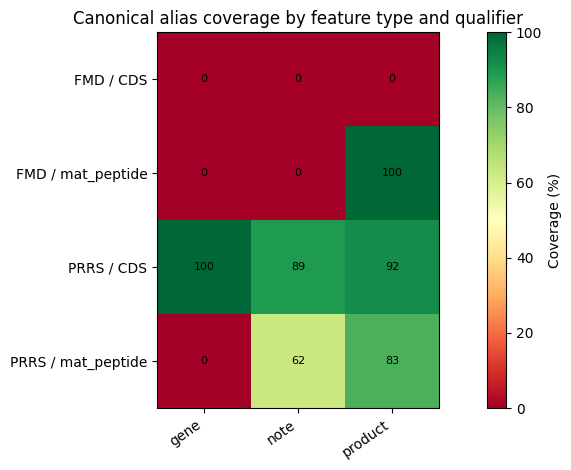

In [8]:
heatmap_df = summary_by_field.copy()
heatmap_df['bucket'] = heatmap_df['virus'] + ' / ' + heatmap_df['feature_type']
heatmap = heatmap_df.pivot_table(index='bucket', columns='field', values='coverage_pct', fill_value=0)
heatmap = heatmap.reindex(sorted(heatmap.index))

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(heatmap.values, vmin=0, vmax=100, cmap='RdYlGn')
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, rotation=35, ha='right')
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_title('Canonical alias coverage by feature type and qualifier')

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        value = heatmap.iloc[i, j]
        ax.text(j, i, f'{value:.0f}', ha='center', va='center', color='black', fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Coverage (%)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'alias_coverage_heatmap.png', dpi=180, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'alias_coverage.png', dpi=180, bbox_inches='tight')
heatmap

## Chart: Top Non-Canonical Names

These are the highest-impact names to inspect first. Red means still unresolved, yellow means intentionally ambiguous, grey means intentionally ignored.

,virus,feature_type,field,status,raw_value,count,occurrence_pct_of_virus
0,FMD,CDS,product,ignored,polyprotein,100,7.82
6,PRRS,CDS,note,ambiguous,envelope protein,4,0.23
7,PRRS,CDS,note,ambiguous,glycoprotein,4,0.23
16,PRRS,CDS,note,ignored,cysteine protease/serine protease,4,0.23
15,PRRS,CDS,note,ignored,structural membrane protein,5,0.28
5,PRRS,CDS,note,ambiguous,glycosylated,6,0.34
14,PRRS,CDS,note,ignored,proteinase,6,0.34
4,PRRS,CDS,product,ambiguous,envelope protein,7,0.40
13,PRRS,CDS,product,ignored,proteinase,11,0.63
3,PRRS,CDS,note,ambiguous,glycosylated membrane protein,13,0.74


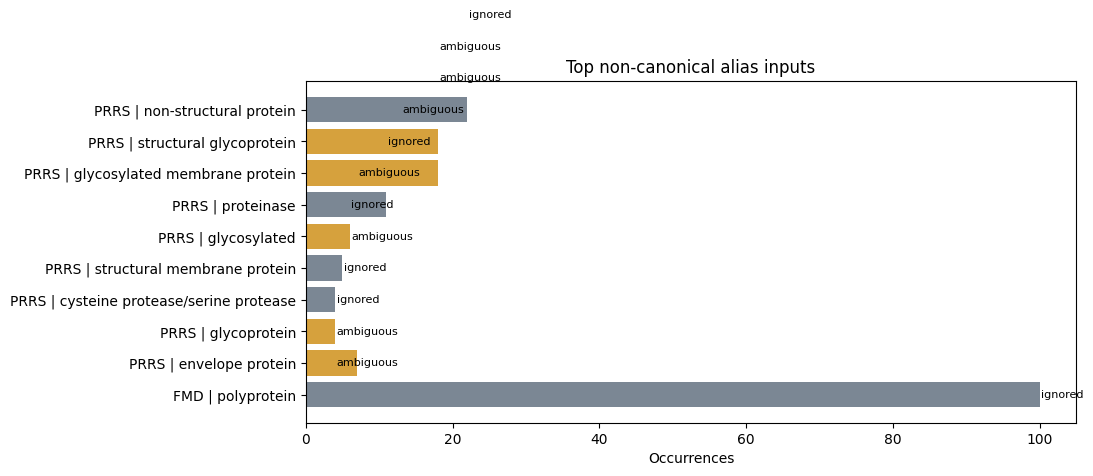

In [9]:
top_noncanonical = (
    noncanonical_names.sort_values(['virus', 'count'], ascending=[True, False])
    .groupby('virus')
    .head(12)
    .copy()
)
top_noncanonical['label'] = top_noncanonical['virus'] + ' | ' + top_noncanonical['raw_value'].str.slice(0, 55)
top_noncanonical = top_noncanonical.sort_values(['virus', 'count'])

fig, ax = plt.subplots(figsize=(11, max(4, 0.38 * len(top_noncanonical))))
colors = top_noncanonical['status'].map(STATUS_COLORS)
ax.barh(top_noncanonical['label'], top_noncanonical['count'], color=colors)
ax.set_xlabel('Occurrences')
ax.set_ylabel('')
ax.set_title('Top non-canonical alias inputs')

for y, (_, row) in enumerate(top_noncanonical.iterrows()):
    ax.text(row['count'] + 0.2, y, row['status'], va='center', fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'alias_top_noncanonical.png', dpi=180, bbox_inches='tight')
top_noncanonical[['virus', 'feature_type', 'field', 'status', 'raw_value', 'count', 'occurrence_pct_of_virus']]